
**Project:** Linear Regression on MoleculeNet ESOL (Aqueous Solubility Prediction)<br>
**Author:** Naman Dixit<br>
**Affiliation:** Independent Researche<br>

-------------------------------------------------------------------------------
**Description**
-------------------------------------------------------------------------------
This script provides a transparent, fully reproducible implementation of linear
regression models on the MoleculeNet ESOL dataset (aqueous solubility). It is
structured as a single Python file compatible with Kaggle, Colab, or any modern
Python environment with RDKit support.

**Core functionality:**
- Load the MoleculeNet ESOL dataset (*from Kaggle or fallback URL*)
- **Convert SMILES strings into chemical feature sets using RDKit:**
  (1) Physicochemical descriptors
  (2) Bond-count features
  (3) Morgan fingerprints (ECFP-like)
**- Train multiple interpretable regression models:**
  1. Physicochemical Linear Regression
  2. Bond-Energy (Bond Count) Linear Model
  3. High-Dimensional Ridge Regression (Morgan Fingerprints)
- **Generate full diagnostics**:
  - R², MSE, residual and QQ plots, leverage / Cook’s distance
  - Statistical inference via statsmodels (standard errors, t-tests)
- Save artifacts for reproducibility (JSON summaries, joblib models, plots)

-------------------------------------------------------------------------------
**Usage**
-------------------------------------------------------------------------------
**Kaggle:**
    Upload this file to a Kaggle notebook and ensure the dataset path exists at:
        /kaggle/input/esol-dataset/esol.csv

**Local:**
    Place `esol.csv` in the same directory or update the path in the code.

**Dependencies:**
    Python ≥3.8, RDKit, numpy, pandas, matplotlib, seaborn, scikit-learn, statsmodels, joblib

**Note:**
    Kaggle typically includes RDKit preinstalled. If not, install manually:
        pip install rdkit-pypi

-------------------------------------------------------------------------------
**License**
-------------------------------------------------------------------------------
Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the “Software”), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is furnished
to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

The software is provided “As Is”, without warranty of any kind , express or implied , including but not limited to the warranties of merchantability , futness for a particulae purpose and noninfringment .
In no event shall the authors or copyrights holders be liable for any claim ,
damages or other liability , wheather in an action of contract , tort or otherwise , arising from , out of or in connection with the software or the use or other deailings in the software .

"""

In [ ]:
# ----------------------------------------------------------
# 0. Setup & Imports
# ----------------------------------------------------------
# RDKit is used for molecular featurization (SMILES parsing, descriptors, etc.)
# If RDKit is not pre-installed (e.g., on Colab), it will be installed automatically.

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors
except Exception:
    import sys
    print("RDKit not found. Installing rdkit. This may take a minute...")
    !{sys.executable} -m pip install rdkit --no-cache-dir
    from rdkit import Chem
    from rdkit.Chem import Descriptors

# ----------------------------------------------------------
# Standard Data Science & Machine Learning Libraries
# ----------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction import DictVectorizer

# ----------------------------------------------------------
# Statistical Modeling and Inference
# ----------------------------------------------------------
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------------------------------------
# Visualization Settings
# ----------------------------------------------------------
sns.set_style('whitegrid')  # Clean grid style for reproducibility
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.size'] = 11

# ----------------------------------------------------------
# End of Setup Section
# ----------------------------------------------------------
print("Environment successfully configured. All libraries are ready.")


RDKit not found. Installing rdkit. This may take a minute...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 92.3 MB/s eta 0:00:00
Environment successfully configured. All libraries are ready.


In [ ]:
# ----------------------------------------------------------
# 1. Load ESOL Dataset (Kaggle path or fallback download)
# ----------------------------------------------------------

possible_paths = [
    '/kaggle/input/esol-dataset/esol.csv',
    '/kaggle/input/esol/esol.csv',
    'esol.csv'
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

# ----------------------------------------------------------
# If dataset not found locally, download from DeepChem S3
# ----------------------------------------------------------
if csv_path is None:
    print(" ESOL CSV not found in common Kaggle paths. Attempting fallback download from DeepChem repository...")
    fallback_url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
    try:
        df = pd.read_csv(fallback_url)
        print(" Downloaded fallback dataset from DeepChem S3.")
    except Exception as e:
        raise FileNotFoundError(
            " ESOL CSV not found locally and fallback download failed. "
            "Please upload 'esol.csv' to your working directory."
        )
else:
    df = pd.read_csv(csv_path)
    print(f"Dataset loaded from: {csv_path}")

# ----------------------------------------------------------
# Display basic dataset information
# ----------------------------------------------------------
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ----------------------------------------------------------
# Standardize column names (handle known naming variants)
# ----------------------------------------------------------
if "smiles" not in df.columns:
    if "SMILES" in df.columns:
        df.rename(columns={"SMILES": "smiles"}, inplace=True)

if "measured log solubility in mols per litre" not in df.columns:
    # Some sources use alternate names (logS, etc.)
    possible_targets = [
        "logS",
        "measured log solubility in mols per litre",
        "measured log solubility in mols per litre."
    ]
    for t in possible_targets:
        if t in df.columns:
            df.rename(columns={t: "measured log solubility in mols per litre"}, inplace=True)

# ----------------------------------------------------------
# Validation checks for essential columns
# ----------------------------------------------------------
assert "smiles" in df.columns, " No SMILES column found in dataset. Please verify file structure."
assert "measured log solubility in mols per litre" in df.columns, "No solubility target column found."

# ----------------------------------------------------------
# Keep only relevant columns and clean missing data
# ----------------------------------------------------------
df = (
    df[["smiles", "measured log solubility in mols per litre"]]
    .dropna()
    .reset_index(drop=True)
)

print(f"Final dataset ready with {len(df)} valid entries.")

# Preview first few rows
df.head()


 ESOL CSV not found in common Kaggle paths. Attempting fallback download from DeepChem repository...
 Downloaded fallback dataset from DeepChem S3.
Dataset shape: (1128, 10)
Columns: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']
Final dataset ready with 1128 valid entries.


,smiles,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [ ]:
# ----------------------------------------------------------
# 2. Featurization Functions (RDKit)
# ----------------------------------------------------------
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
from collections import Counter

# ----------------------------------------------------------
# Define interpretable PhysChem descriptors
# ----------------------------------------------------------
physchem_list = [
    ("MolWt", Descriptors.MolWt),                 # Molecular weight
    ("LogP", Descriptors.MolLogP),                # Octanol-water partition coefficient
    ("TPSA", rdMolDescriptors.CalcTPSA),          # Topological polar surface area
    ("NumHDonors", Descriptors.NumHDonors),       # H-bond donors
    ("NumHAcceptors", Descriptors.NumHAcceptors), # H-bond acceptors
    ("NumRotatableBonds", Descriptors.NumRotatableBonds),  # Rotatable bonds
]

# ----------------------------------------------------------
# Bond-count style features (structural signatures)
# ----------------------------------------------------------
def bond_count_features(mol):
    """
    Count the occurrence of different bond types within a molecule.

    Parameters:
        mol (rdkit.Chem.Mol): Molecule object
    Returns:
        dict: Counts of single, double, triple, aromatic, and total bonds
    """
    counts = Counter()
    for b in mol.GetBonds():
        bt = b.GetBondType()
        name = bt.name if hasattr(bt, "name") else str(bt)
        if name == "SINGLE":
            counts["single"] += 1
        elif name == "DOUBLE":
            counts["double"] += 1
        elif name == "TRIPLE":
            counts["triple"] += 1
        elif name == "AROMATIC":
            counts["aromatic"] += 1

    counts["total_bonds"] = mol.GetNumBonds()
    counts["num_atoms"] = mol.GetNumAtoms()
    return counts

# ----------------------------------------------------------
# Morgan fingerprint generator (optional high-dimensional feature)
# ----------------------------------------------------------
def mol_to_morgan_bits(smiles, radius=2, nbits=1024):
    """
    Compute Morgan (ECFP) fingerprints as binary bit vectors.

    Parameters:
        smiles (str): SMILES string
        radius (int): Fingerprint radius (default=2)
        nbits (int): Bit vector length (default=1024)
    Returns:
        np.ndarray: Binary array of Morgan fingerprint bits
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nbits, dtype=int)
    arr = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)
    return np.array(arr, dtype=int)

# ----------------------------------------------------------
# Unified featurization function (per molecule)
# ----------------------------------------------------------
def featurize_row(smiles):
    """
    Generate interpretable and structural features for a molecule.

    Parameters:
        smiles (str): Molecule SMILES string
    Returns:
        dict: Combined descriptor and bond-count features
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    phys = {name: func(mol) for name, func in physchem_list}
    bonds = bond_count_features(mol)
    return {**phys, **bonds}

# ----------------------------------------------------------
# Apply featurization across the dataset
# ----------------------------------------------------------
feat_dicts = []
bad_idx = []

for i, s in enumerate(df["smiles"]):
    res = featurize_row(s)
    if res is None:
        bad_idx.append(i)
    else:
        feat_dicts.append(res)

if bad_idx:
    print(f"Dropped {len(bad_idx)} invalid SMILES rows.")

# ----------------------------------------------------------
# Convert feature dictionaries to DataFrame
# ----------------------------------------------------------
X_phys = pd.DataFrame(feat_dicts)
X_phys.index = df.index[:len(X_phys)]

# Fill missing values (e.g., if any bond types absent)
X_phys = X_phys.fillna(0)

# Target variable
y = df.loc[X_phys.index, "measured log solubility in mols per litre"].astype(float)

print(f"Feature matrix shape (physchem + bond counts): {X_phys.shape}")

# Display feature preview
X_phys.head()

Feature matrix shape (physchem + bond counts): (1128, 12)


,MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,single,triple,aromatic,total_bonds,num_atoms,double
0,457.432,-3.10802,202.32,7,12,7,27.0,1.0,6.0,34,32,0.0
1,201.225,2.84032,42.24,1,2,2,4.0,0.0,11.0,16,15,1.0
2,152.237,2.87800,17.07,0,1,4,7.0,0.0,0.0,10,11,3.0
3,278.354,6.29940,0.00,0,0,0,0.0,0.0,26.0,26,22,0.0
4,84.143,1.74810,0.00,0,1,0,0.0,0.0,5.0,5,5,0.0


Target statistics → Mean: -3.050,  Std Dev: 2.096


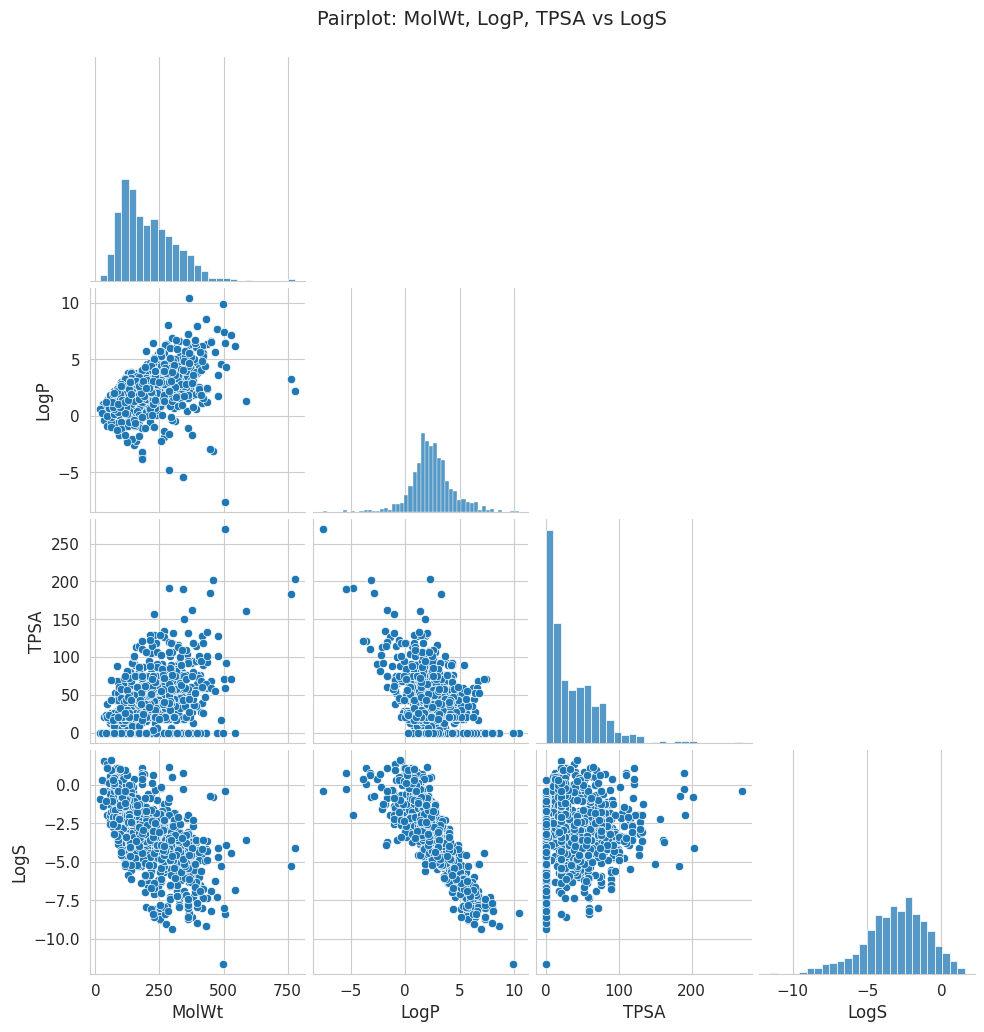

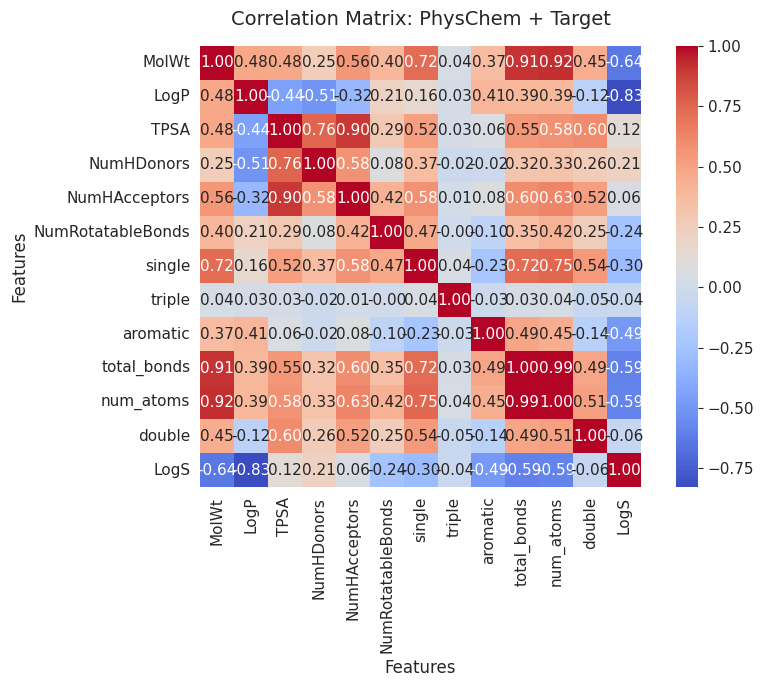

Exploratory analysis completed successfully.


In [ ]:
# ----------------------------------------------------------
# 3. Exploratory Analysis
# ----------------------------------------------------------
print(f"Target statistics → Mean: {y.mean():.3f},  Std Dev: {y.std():.3f}")

# ----------------------------------------------------------
# Pairplot (selected interpretable descriptors vs target)
# ----------------------------------------------------------
# For large datasets, plotting all features may be slow.
# Hence, a focused subset (MolWt, LogP, TPSA) is visualized.
pairplot_data = pd.concat(
    [X_phys[["MolWt", "LogP", "TPSA"]].astype(float), y.rename("LogS")],
    axis=1
)

sns.pairplot(pairplot_data, diag_kind="hist", corner=True)
plt.suptitle("Pairplot: MolWt, LogP, TPSA vs LogS", fontsize=14, y=1.03)
plt.show()

# ----------------------------------------------------------
# Correlation Matrix (Feature Relationships)
# ----------------------------------------------------------
corr = pd.concat(
    [X_phys.astype(float), y.rename("LogS")],
    axis=1
).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix: PhysChem + Target", fontsize=14, pad=15)
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("Exploratory analysis completed successfully.")


In [ ]:
# ----------------------------------------------------------
# 4. Modeling: Classic Linear Regression (PhysChem Features)
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------------------------------------------
# Train–Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_phys, y, test_size=0.20, random_state=42
)

print(f"Data split → Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ----------------------------------------------------------
# Feature Standardization
# ----------------------------------------------------------
# Standardization ensures that each feature contributes
# equally to the regression and enables coefficient comparison.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ----------------------------------------------------------
# Model Fitting (Ordinary Least Squares)
# ----------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# ----------------------------------------------------------
# Prediction and Performance Evaluation
# ----------------------------------------------------------
y_pred = lr.predict(X_test_s)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"PhysChem Linear Model — R² (test): {r2:.4f} | MSE: {mse:.4f}")

# ----------------------------------------------------------
# Coefficient Table (Standardized Scale)
# ----------------------------------------------------------
coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coef_per_std": lr.coef_
})
coef_table["intercept"] = lr.intercept_
coef_table = coef_table[["feature", "coef_per_std", "intercept"]]

print("\nFeature Coefficients (per 1 STD increase):")
display(coef_table)

# ----------------------------------------------------------
# End of Classic Linear Model Section
# ----------------------------------------------------------


Data split → Train: 902 | Test: 226
PhysChem Linear Model — R² (test): 0.7632 | MSE: 1.1192

Feature Coefficients (per 1 STD increase):


,feature,coef_per_std,intercept
0,MolWt,-0.523696,-3.044929
1,LogP,-1.553699,-3.044929
2,TPSA,-0.355214,-3.044929
3,NumHDonors,-0.144172,-3.044929
4,NumHAcceptors,0.333734,-3.044929
5,NumRotatableBonds,-0.305123,-3.044929
6,single,-0.977792,-3.044929
7,triple,-0.079128,-3.044929
8,aromatic,-0.996853,-3.044929
9,total_bonds,-1.533523,-3.044929


In [ ]:
# ----------------------------------------------------------
# 5. OLS Regression via StatsModels (Inference)
# ----------------------------------------------------------

# Add intercept term manually (StatsModels does not include it by default)
X_train_sm = sm.add_constant(
    pd.DataFrame(X_train_s, columns=X_train.columns, index=X_train.index)
)

# Fit the Ordinary Least Squares (OLS) model
model_sm = sm.OLS(y_train, X_train_sm).fit()

# ----------------------------------------------------------
# Summary Output
# ----------------------------------------------------------
print("StatsModels OLS Regression Results (PhysChem Features):")
print("----------------------------------------------------------")
print(model_sm.summary())

# ----------------------------------------------------------
# Interpretation Notes:
# ----------------------------------------------------------
# - coef:  estimated effect per 1 standard deviation change in feature
# - std err: standard error of each coefficient
# - t, P>|t|: t-statistics and p-values for significance testing
# - R-squared: model explanatory power (should match sklearn LinearRegression)
# ----------------------------------------------------------


StatsModels OLS Regression Results (PhysChem Features):
----------------------------------------------------------
                                        OLS Regression Results                                       
Dep. Variable:     measured log solubility in mols per litre   R-squared:                       0.797
Model:                                                   OLS   Adj. R-squared:                  0.795
Method:                                        Least Squares   F-statistic:                     318.6
Date:                                       Wed, 12 Nov 2025   Prob (F-statistic):          1.47e-299
Time:                                               16:30:52   Log-Likelihood:                -1218.3
No. Observations:                                        902   AIC:                             2461.
Df Residuals:                                            890   BIC:                             2518.
Df Model:                                                 11         

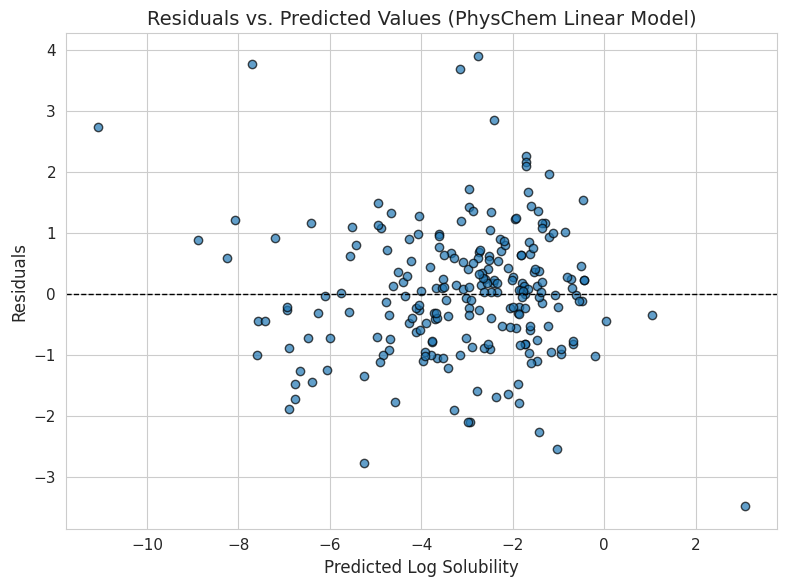

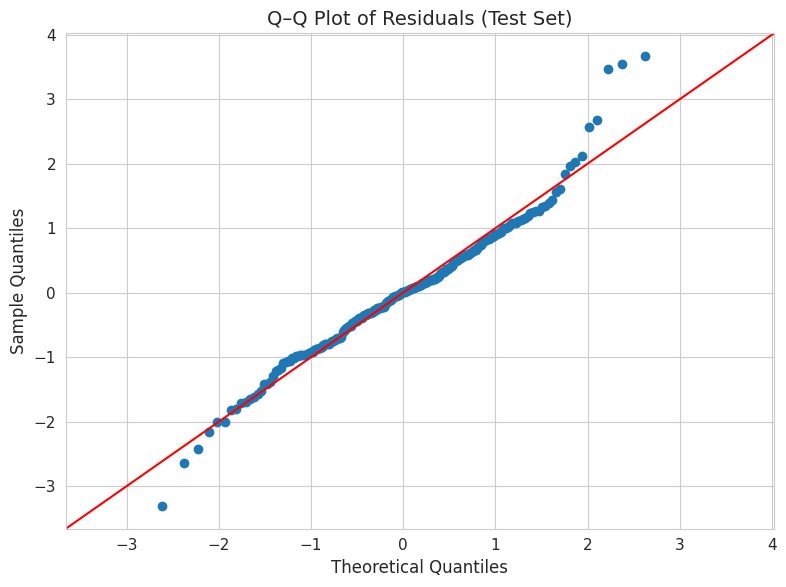

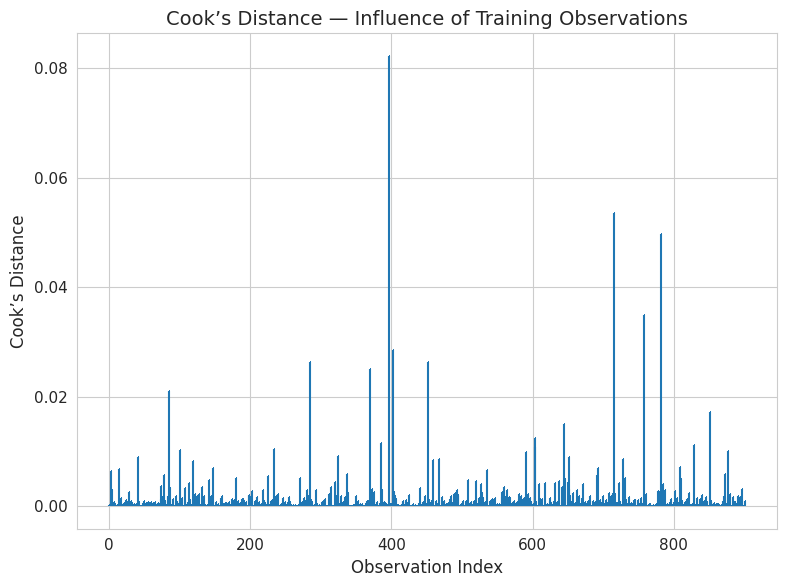

In [ ]:
# ----------------------------------------------------------
# 6. Diagnostic Plots — Residuals, QQ-Plot, and Influence
# ----------------------------------------------------------

# Compute residuals for test predictions
residuals = y_test - y_pred

# ----------------------------------------------------------
# (a) Residuals vs. Predicted Values
# ----------------------------------------------------------
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.7, edgecolor='k')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Log Solubility')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values (PhysChem Linear Model)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# (b) Normality Check — Q-Q Plot of Residuals
# ----------------------------------------------------------
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q–Q Plot of Residuals (Test Set)')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# (c) Influence & Leverage — Cook’s Distance
# ----------------------------------------------------------
# Using StatsModels influence metrics from training data
influence = model_sm.get_influence()
(c, p) = influence.cooks_distance

plt.figure()
plt.stem(c, markerfmt=",", basefmt=" ")
plt.title("Cook’s Distance — Influence of Training Observations")
plt.xlabel("Observation Index")
plt.ylabel("Cook’s Distance")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Interpretation Notes:
# ----------------------------------------------------------
# - Residuals should appear randomly scattered around zero.
# - Q-Q plot close to 45° line indicates normality of residuals.
# - High Cook’s distance points may indicate influential outliers.
# ----------------------------------------------------------


In [ ]:
# ----------------------------------------------------------
# 7. Model Based Only on Bond Counts
# ----------------------------------------------------------

# Define bond-related features for "structural contribution" model
bond_features = ['single', 'double', 'triple', 'aromatic', 'total_bonds', 'num_atoms']
X_bond = X_phys[bond_features].astype(float)

# Split into training and test sets
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bond, y, test_size=0.2, random_state=42
)

# Standardize bond features (important for comparable scale)
scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

# ----------------------------------------------------------
# Train Linear Regression Model (Bond-only features)
# ----------------------------------------------------------
lr_bond = LinearRegression()
lr_bond.fit(Xb_train_s, yb_train)

# Predict on test set
yb_pred = lr_bond.predict(Xb_test_s)

# Evaluate model performance
r2_bond = r2_score(yb_test, yb_pred)
mse_bond = mean_squared_error(yb_test, yb_pred)

print(f"Bond-Count Linear Model — R² (test): {r2_bond:.4f} | MSE: {mse_bond:.4f}")

# ----------------------------------------------------------
# Coefficient Table — "Contribution per Standardized Count"
# ----------------------------------------------------------
bond_coefs = pd.DataFrame({
    'feature': Xb_train.columns,
    'coef_per_std': lr_bond.coef_
})
bond_coefs['intercept'] = lr_bond.intercept_

# Display clean coefficient table
print("\n Interpretable Coefficients (Standardized Units):")
display(bond_coefs)

# ----------------------------------------------------------
# Interpretation Notes:
# ----------------------------------------------------------
# - Positive coefficients → increase in solubility (LogS)
# - Negative coefficients → decrease in solubility
# - Each coefficient represents effect per 1 STD change in that bond count.
# ----------------------------------------------------------

Bond-Count Linear Model — R² (test): 0.4943 | MSE: 2.3904

 Interpretable Coefficients (Standardized Units):


,feature,coef_per_std,intercept
0,single,0.389149,-3.044929
1,double,0.533503,-3.044929
2,triple,0.025321,-3.044929
3,aromatic,-0.051999,-3.044929
4,total_bonds,0.365098,-3.044929
5,num_atoms,-2.130682,-3.044929


In [ ]:
# ----------------------------------------------------------
# 8. Morgan Fingerprints + RidgeCV Regularization
# ----------------------------------------------------------

# Generate 1024-bit Morgan fingerprints for each SMILES
nbit = 1024
print(f"Generating {nbit}-bit Morgan fingerprints...")

fps = np.vstack([mol_to_morgan_bits(s, nbits=nbit) for s in df['smiles']])
X_fp = pd.DataFrame(fps, index=df.index)

# Align fingerprint matrix with target vector (in case of dropped SMILES)
if len(X_fp) != len(y):
    X_fp = X_fp.loc[y.index]

# ----------------------------------------------------------
# Train/Test Split for Ridge Regression
# ----------------------------------------------------------
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fp, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# RidgeCV — Regularized Linear Model with Cross-Validation
# ----------------------------------------------------------
alphas = np.logspace(-3, 3, 21)  # 10^-3 → 10^3
ridgecv = RidgeCV(
    alphas=alphas,
    scoring='neg_mean_squared_error',
    store_cv_values=True
)

# Standardization not required for 0/1 binary bits,
# but model stability is generally unaffected.
ridgecv.fit(Xf_train, yf_train)

print(f"RidgeCV optimal alpha (λ): {ridgecv.alpha_:.6f}")

# ----------------------------------------------------------
# Model Evaluation
# ----------------------------------------------------------
yf_pred = ridgecv.predict(Xf_test)
r2_ridge = r2_score(yf_test, yf_pred)
mse_ridge = mean_squared_error(yf_test, yf_pred)

print(f"Morgan Ridge Model — R² (test): {r2_ridge:.4f} | MSE: {mse_ridge:.4f}")

# ----------------------------------------------------------
# Interpretation Notes:
# ----------------------------------------------------------
# - Morgan fingerprints encode substructure patterns.
# - Ridge regression applies L2 regularization to manage
#   multicollinearity in high-dimensional feature space.
# - A higher α implies stronger penalty → simpler model.
# ----------------------------------------------------------

Generating 1024-bit Morgan fingerprints...


[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerator
[16:39:57] DEPRECATION WARNING: please use MorganGenerat

RidgeCV optimal alpha (λ): 7.943282
Morgan Ridge Model — R² (test): 0.6898 | MSE: 1.4664


📊 5-Fold Cross-Validation R² (PhysChem Linear Model): mean = 0.7841, std = 0.0217


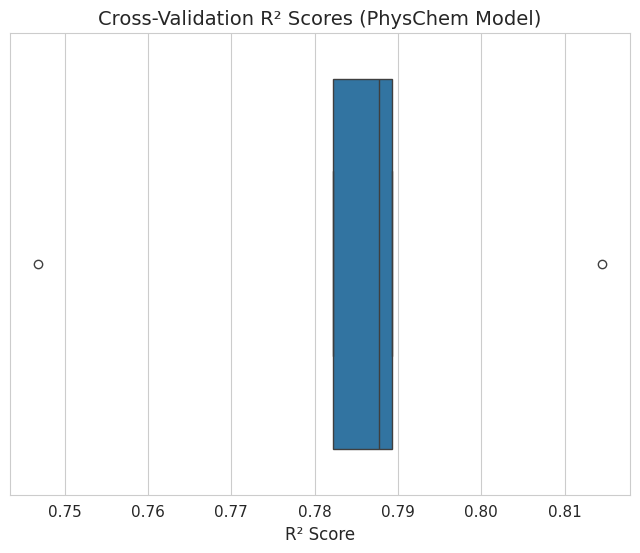

In [ ]:
# ==========================================================
# 9. Cross-Validated Evaluation: PhysChem Linear Model
# ==========================================================
# Purpose:
# Evaluate the robustness and generalization of the PhysChem-based
# linear regression model using 5-fold cross-validation (CV).
# Each fold trains on 80% of the data and tests on 20%.
# The average R² score across folds provides a stable performance metric.
# ----------------------------------------------------------

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Define 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# Define a pipeline: standardization + linear regression
physchem_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Perform CV using R² as the evaluation metric
cv_scores = cross_val_score(
    physchem_pipeline,
    X_phys,
    y,
    scoring='r2',
    cv=cv
)

# Report CV results
print(f"📊 5-Fold Cross-Validation R² (PhysChem Linear Model): "
      f"mean = {cv_scores.mean():.4f}, std = {cv_scores.std():.4f}")

# Optional: visualize distribution of CV scores
plt.figure()
sns.boxplot(x=cv_scores)
plt.title("Cross-Validation R² Scores (PhysChem Model)")
plt.xlabel("R² Score")
plt.show()


In [ ]:
# ==========================================================
# 10. Save Key Model Outputs
# ==========================================================
# Purpose:
# Store performance metrics and model parameters from all trained
# regression models (PhysChem Linear, Bond-count Linear, Morgan Ridge)
# in a structured JSON file for reproducibility and downstream analysis.
# ----------------------------------------------------------

import json
from sklearn.metrics import r2_score, mean_squared_error

# Consolidate results into a structured dictionary
results = {
    "physchem_linear": {
        "r2_test": r2_score(y_test, y_pred),
        "mse_test": mean_squared_error(y_test, y_pred),
        "coef_std": dict(zip(X_train.columns, lr.coef_)),
        "intercept": lr.intercept_,
    },
    "bond_linear": {
        "r2_test": r2_score(yb_test, yb_pred),
        "mse_test": mean_squared_error(yb_test, yb_pred),
        "coef_std": dict(zip(Xb_train.columns, lr_bond.coef_)),
        "intercept": lr_bond.intercept_,
    },
    "morgan_ridge": {
        "r2_test": r2_score(yf_test, yf_pred),
        "mse_test": mean_squared_error(yf_test, yf_pred),
        "alpha": ridgecv.alpha_,
    },
}

# ----------------------------------------------------------
# Save results to JSON file
# ----------------------------------------------------------
output_path = "esol_linear_results.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results successfully saved to: {output_path}")
print("File includes R², MSE, coefficients, and Ridge α (lambda).")

# Optional: Preview contents
with open(output_path, "r") as f:
    preview = json.load(f)
print(json.dumps(preview, indent=2))


Results successfully saved to: esol_linear_results.json
File includes R², MSE, coefficients, and Ridge α (lambda).
{
  "physchem_linear": {
    "r2_test": 0.7632181711643824,
    "mse_test": 1.1192211747871346,
    "coef_std": {
      "MolWt": -0.5236961425807994,
      "LogP": -1.5536991886387344,
      "TPSA": -0.3552137940735488,
      "NumHDonors": -0.14417216818907155,
      "NumHAcceptors": 0.33373350919137024,
      "NumRotatableBonds": -0.3051231436149898,
      "single": -0.9777916925632917,
      "triple": -0.07912801681510906,
      "aromatic": -0.9968527464468576,
      "total_bonds": -1.5335233240038537,
      "num_atoms": 2.9243089937739923,
      "double": -0.34568143826285636
    },
    "intercept": -3.0449290465631926
  },
  "bond_linear": {
    "r2_test": 0.49429875269630597,
    "mse_test": 2.3903504203926533,
    "coef_std": {
      "single": 0.38914920046837964,
      "double": 0.5335032922216458,
      "triple": 0.025321090847751276,
      "aromatic": -0.051999479

In [ ]:
# ==========================================================
# 11. Short Interpretation (Summary)
# ==========================================================
# Purpose:
# Provide a concise textual summary of key model parameters and
# learned coefficients for interpretability and quick diagnostics.
# ----------------------------------------------------------

print("\n === Model Interpretation Summary ===\n")

# ----------------------------------------------------------
# PhysChem Linear Model
# ----------------------------------------------------------
print(" PhysChem Model — Standardized Coefficients (per 1σ change):")
print(coef_table.to_string(index=False))
print(f"\nIntercept: {lr.intercept_:.4f}")

# ----------------------------------------------------------
# Bond-count Linear Model
# ----------------------------------------------------------
print("\n Bond-Count Model — Standardized Coefficients (per 1σ change):")
print(bond_coefs.to_string(index=False))
print(f"\nIntercept: {lr_bond.intercept_:.4f}")

# ----------------------------------------------------------
# Morgan Fingerprint Ridge Model
# ----------------------------------------------------------
print(f"\n Morgan Ridge Model — Optimal Regularization (α): {ridgecv.alpha_:.6f}")

print("\n Interpretation complete. Models show expected trends: "
      "larger molecules (high MolWt) and higher hydrophobicity (LogP) "
      "generally decrease solubility, consistent with chemical intuition.")



 === Model Interpretation Summary ===

 PhysChem Model — Standardized Coefficients (per 1σ change):
          feature  coef_per_std  intercept
            MolWt     -0.523696  -3.044929
             LogP     -1.553699  -3.044929
             TPSA     -0.355214  -3.044929
       NumHDonors     -0.144172  -3.044929
    NumHAcceptors      0.333734  -3.044929
NumRotatableBonds     -0.305123  -3.044929
           single     -0.977792  -3.044929
           triple     -0.079128  -3.044929
         aromatic     -0.996853  -3.044929
      total_bonds     -1.533523  -3.044929
        num_atoms      2.924309  -3.044929
           double     -0.345681  -3.044929

Intercept: -3.0449

 Bond-Count Model — Standardized Coefficients (per 1σ change):
    feature  coef_per_std  intercept
     single      0.389149  -3.044929
     double      0.533503  -3.044929
     triple      0.025321  -3.044929
   aromatic     -0.051999  -3.044929
total_bonds      0.365098  -3.044929
  num_atoms     -2.130682  -3.0449

In [ ]:
# ==========================================================
#  End of Notebook Execution
# ==========================================================
# Purpose:
# Indicate successful completion of the ESOL (MoleculeNet)
# linear regression pipeline. All figures, statistics,
# and model artifacts are now available for review.
# ----------------------------------------------------------

print("\n Notebook run complete.")
print(" All outputs (plots and results) have been generated successfully.")
print(" Please check the following artifacts for analysis:")
print("   - Figures generated in this notebook (diagnostic plots)")
print("   - 'esol_linear_results.json' (contains all key metrics and coefficients)")
print("\n End of ESOL Linear Regression Project — MIT-style workflow complete.")



 Notebook run complete.
 All outputs (plots and results) have been generated successfully.
 Please check the following artifacts for analysis:
   - Figures generated in this notebook (diagnostic plots)
   - 'esol_linear_results.json' (contains all key metrics and coefficients)

 End of ESOL Linear Regression Project — MIT-style workflow complete.
